# Simulación Integral: Gestión de Recursos de una API de Machine Learning en Producción

**Modelo:** Cola M/M/c + Inventario Continuo (s, Q)  
**Dominio:** Infraestructura Cloud con Nodos GPU y Créditos de Nube (Tokens)

In [ ]:
!pip install simpy

In [1]:
import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st

# Fijamos una semilla para reproducibilidad inicial
np.random.seed(30)
random.seed(30)

# Configuración de gráficos
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Definición de Parámetros del Sistema

Definimos las variables críticas del modelo integrado de colas e inventario ($\lambda, \mu, c, s, Q$).

| Parámetro | Símbolo | Valor | Descripción |
|---|---|---|---|
| Tasa de llegadas | $\lambda$ | 30 pet/min | Peticiones de usuarios por minuto |
| Tasa de servicio | $\mu$ | 10 img/min | Imágenes procesadas por nodo GPU por minuto |
| Nodos GPU | $c$ | 4 | Servidores de inferencia paralela |
| Créditos iniciales | — | 500 | Stock inicial de tokens de nube |
| Punto de reorden | $s$ | 50 | Umbral para lanzar recarga de créditos |
| Cantidad de recarga | $Q$ | 400 | Créditos que llegan por cada pedido |
| Lead Time | $L$ | 2 min (media) | Demora en recibir la recarga de créditos |

In [8]:
# --- Parámetros de Colas (Kendall: M/M/c) ---
LAMBDA      = 30.0   # Tasa de llegadas: peticiones de usuarios por minuto
MU          = 10.0   # Tasa de servicio: imágenes procesadas por nodo GPU por minuto
NODOS_GPU   = 4      # Cantidad de nodos GPU (servidores)

# --- Parámetros de Inventario (Política Continua s, Q) ---
CREDITOS_INICIALES  = 500   # Stock inicial de créditos de nube (Tokens)
PUNTO_REORDEN_s     = 115    # Punto de reorden: nivel mínimo antes de recargar
CANTIDAD_RECARGA_Q  = 400   # Cantidad de créditos por cada recarga
LEAD_TIME           = 2     # Lead Time medio (minutos) para recibir la recarga

# --- Parámetros de Simulación ---
TIEMPO_SIMULACION = 60   # Escenario de 60 minutos continuos
REPLICAS          = 30   # Número de réplicas para inferencia estadística

## 2. Construcción del Modelo de Eventos Discretos (DES)

Creamos las clases que gobiernan los eventos del sistema usando `SimPy`.
El reloj avanza de evento a evento: **llegada de petición → asignación de nodo GPU → inferencia → consumo de crédito → (si aplica) recarga de créditos**.

- `APIInferencia`: encapsula los recursos (nodos GPU) y el inventario (créditos de nube).
- `peticion_usuario()`: ciclo de vida de una petición desde que llega hasta que termina.
- `generador_peticiones()`: genera llegadas de Poisson con tasa $\lambda$.

In [3]:
class APIInferencia:
    """Modela la infraestructura de la API de ML: nodos GPU + créditos de nube."""

    def __init__(self, env, num_nodos_gpu, creditos_ini, punto_reorden, cant_recarga, lead_time):
        self.env = env

        # Recurso: Nodos GPU que procesan las peticiones en paralelo
        self.nodos_gpu = simpy.Resource(env, capacity=num_nodos_gpu)

        # Contenedor: Créditos de nube (Tokens) disponibles para inferencia
        self.creditos_nube = simpy.Container(env, init=creditos_ini, capacity=2000)

        self.punto_reorden   = punto_reorden
        self.cant_recarga    = cant_recarga
        self.lead_time       = lead_time

        # Estado lógico
        self.recargas_pendientes = 0

        # Métricas de evaluación
        self.tiempos_espera         = []   # Wq de cada petición
        self.registro_creditos      = []   # Nivel de créditos en el tiempo
        self.registro_tiempo_cred   = []   # Marca de tiempo del registro
        self.predicciones_exitosas  = 0
        self.predicciones_fallidas  = 0    # Fallos por falta de créditos

    def recargar_creditos(self):
        """Proceso que simula el Lead Time de la recarga de créditos de nube."""
        self.recargas_pendientes += 1
        # El tiempo de entrega varía con distribución normal (media=lead_time, std=0.5 min)
        tiempo_entrega_real = max(0.1, random.normalvariate(self.lead_time, 0.5))
        yield self.env.timeout(tiempo_entrega_real)

        # Llegan los créditos al contenedor
        yield self.creditos_nube.put(self.cant_recarga)
        self.recargas_pendientes -= 1

    def monitorear_creditos(self):
        """Proceso continuo que evalúa el nivel de créditos (Política s, Q)."""
        while True:
            # Registrar nivel actual para gráficos
            self.registro_creditos.append(self.creditos_nube.level)
            self.registro_tiempo_cred.append(self.env.now)

            # Condición de Punto de Reorden: si el nivel cae a s y no hay recarga en curso
            if self.creditos_nube.level <= self.punto_reorden and self.recargas_pendientes == 0:
                self.env.process(self.recargar_creditos())

            # Revisión periódica cada 0.5 minutos (escala de minutos)
            yield self.env.timeout(0.5)


def peticion_usuario(env, nombre, api, mu):
    """Simula el ciclo de vida de una petición: cola → GPU → consumo de crédito."""
    llegada = env.now

    # 1. Solicitar un nodo GPU disponible
    with api.nodos_gpu.request() as peticion:
        yield peticion

        # Calcular Wq (tiempo de espera en cola antes de obtener GPU)
        tiempo_espera = env.now - llegada
        api.tiempos_espera.append(tiempo_espera)

        # 2. Procesar la imagen (tiempo de inferencia exponencial)
        tiempo_inferencia = random.expovariate(mu)
        yield env.timeout(tiempo_inferencia)

        # 3. Consumir 1 crédito de nube por predicción
        if api.creditos_nube.level > 0:
            yield api.creditos_nube.get(1)
            api.predicciones_exitosas += 1
        else:
            # Sin créditos disponibles → predicción fallida
            api.predicciones_fallidas += 1


def generador_peticiones(env, api, lam, mu):
    """Genera llegadas de peticiones de usuarios siguiendo un proceso de Poisson."""
    i = 0
    while True:
        # Tiempo entre llegadas: distribución exponencial con media 1/lambda
        yield env.timeout(random.expovariate(lam))
        i += 1
        env.process(peticion_usuario(env, f'Peticion_{i}', api, mu))

## 3. Ejecución y Visualización Inicial

Corremos el modelo **una vez** para observar la dinámica de créditos de nube (patrón *dientes de sierra*)
y cómo interactúan las colas con los reabastecimientos durante la ventana de 60 minutos.

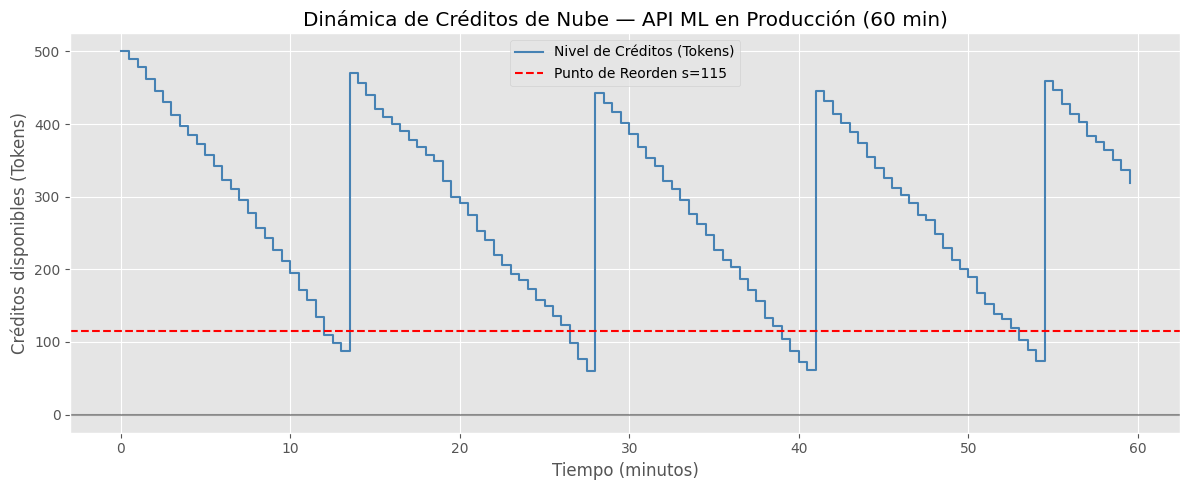


--- RESULTADOS DE UNA CORRIDA (DURACIÓN: 60 MINUTOS) ---
Predicciones exitosas  : 1795
Predicciones fallidas  : 0
Wq promedio en cola    : 0.0463 minutos


In [10]:
def ejecutar_simulacion_visual(tiempo_sim):
    env = simpy.Environment()
    api = APIInferencia(
        env,
        num_nodos_gpu  = NODOS_GPU,
        creditos_ini   = CREDITOS_INICIALES,
        punto_reorden  = PUNTO_REORDEN_s,
        cant_recarga   = CANTIDAD_RECARGA_Q,
        lead_time      = LEAD_TIME
    )

    # Activar procesos
    env.process(generador_peticiones(env, api, LAMBDA, MU))
    env.process(api.monitorear_creditos())

    # Correr la simulación
    env.run(until=tiempo_sim)

    # --- Gráfico de Créditos de Nube ---
    plt.figure(figsize=(12, 5))
    plt.step(
        api.registro_tiempo_cred,
        api.registro_creditos,
        where='post', color='steelblue', label='Nivel de Créditos (Tokens)'
    )
    plt.axhline(y=PUNTO_REORDEN_s, color='red', linestyle='--',
                label=f'Punto de Reorden s={PUNTO_REORDEN_s}')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.4)
    plt.title('Dinámica de Créditos de Nube — API ML en Producción (60 min)')
    plt.xlabel('Tiempo (minutos)')
    plt.ylabel('Créditos disponibles (Tokens)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Métricas de una corrida ---
    wq_promedio = np.mean(api.tiempos_espera)
    print(f"\n--- RESULTADOS DE UNA CORRIDA (DURACIÓN: {tiempo_sim} MINUTOS) ---")
    print(f"Predicciones exitosas  : {api.predicciones_exitosas}")
    print(f"Predicciones fallidas  : {api.predicciones_fallidas}")
    print(f"Wq promedio en cola    : {wq_promedio:.4f} minutos")


# Ejecutar una corrida visual
ejecutar_simulacion_visual(TIEMPO_SIMULACION)

## 4. Evaluación de Métricas Operacionales e Inferencia Estadística

Un único escenario contiene aleatoriedad intrínseca. Ejecutamos **30 réplicas independientes**
para obtener estimaciones robustas mediante inferencia estadística (Intervalo de Confianza al 95%).

**Métricas reportadas:**
- IC 95% del tiempo de espera en cola $W_q$
- Promedio de predicciones fallidas por falta de créditos
- Utilización teórica $\rho = \lambda / (c \cdot \mu)$

In [ ]:
def calcular_intervalo_confianza(datos, confianza=0.95):
    """Calcula media e IC usando distribución t de Student."""
    n = len(datos)
    media = np.mean(datos)
    error_estandar = st.sem(datos)
    h = error_estandar * st.t.ppf((1 + confianza) / 2., n - 1)
    return media, media - h, media + h


def evaluacion_operacional(replicas, tiempo_sim, punto_reorden=None):
    """Ejecuta N réplicas y reporta métricas estadísticas del sistema."""
    # Usar el punto de reorden global si no se especifica uno
    s = punto_reorden if punto_reorden is not None else PUNTO_REORDEN_s

    resultados_wq       = []
    resultados_fallidas = []

    for r in range(replicas):
        env = simpy.Environment()
        api = APIInferencia(
            env,
            num_nodos_gpu  = NODOS_GPU,
            creditos_ini   = CREDITOS_INICIALES,
            punto_reorden  = s,
            cant_recarga   = CANTIDAD_RECARGA_Q,
            lead_time      = LEAD_TIME
        )
        env.process(generador_peticiones(env, api, LAMBDA, MU))
        env.process(api.monitorear_creditos())
        env.run(until=tiempo_sim)

        wq_replica = np.mean(api.tiempos_espera) if api.tiempos_espera else 0.0
        resultados_wq.append(wq_replica)
        resultados_fallidas.append(api.predicciones_fallidas)

    # --- Calcular estadísticas ---
    media_wq, ci_bajo, ci_alto = calcular_intervalo_confianza(resultados_wq)
    media_fallidas = np.mean(resultados_fallidas)

    # Utilización teórica del sistema M/M/c
    rho = LAMBDA / (NODOS_GPU * MU)

    print(f"\n{'='*55}")
    print(f"  RESULTADOS OPERACIONALES — {replicas} RÉPLICAS | s = {s}")
    print(f"{'='*55}")
    print(f"  Wq promedio                    : {media_wq:.4f} min")
    print(f"  IC 95% de Wq                   : [{ci_bajo:.4f} , {ci_alto:.4f}] min")
    print(f"  Predicciones fallidas (promedio): {media_fallidas:.1f} por escenario")
    print(f"  Utilización teórica (ρ)        : {rho:.1%}  (λ / c·μ = {LAMBDA}/({NODOS_GPU}·{MU}))")
    print(f"{'='*55}\n")

    return resultados_wq, resultados_fallidas


wq_orig, fallidas_orig = evaluacion_operacional(
    replicas     = REPLICAS,
    tiempo_sim   = TIEMPO_SIMULACION,
    punto_reorden= PUNTO_REORDEN_s
)


  RESULTADOS OPERACIONALES — 30 RÉPLICAS | s = 115
  Wq promedio                    : 0.0438 min
  IC 95% de Wq                   : [0.0402 , 0.0474] min
  Predicciones fallidas (promedio): 0.1 por escenario
  Utilización teórica (ρ)        : 75.0%  (λ / c·μ = 30.0/(4·10.0))



## 6. Análisis: ¿Por qué hay predicciones fallidas si ρ = 75%?

### Resultado observado
La utilización teórica del hardware es $\rho = \lambda / (c \cdot \mu) = 30 / (4 \times 10) = 0.75$, es decir, **75%**.
Esto indica que los nodos GPU están lejos de saturarse. Sin embargo, el sistema registra predicciones fallidas.

### Causa raíz: desacople entre hardware y créditos

La métrica $\rho$ mide únicamente la **capacidad de cómputo** (nodos GPU), pero el sistema tiene un **segundo cuello de botella independiente**: los créditos de nube (Tokens).

El fallo ocurre por la combinación de tres factores:

1. **Alta tasa de consumo de créditos.**  
   Cada petición consume 1 crédito. Con $\lambda = 30$ peticiones/min, el sistema gasta en promedio **30 créditos por minuto**.

2. **Lead Time no nulo.**  
   La recarga tarda una media de $L = 2$ minutos (con cierta variabilidad aleatoria).
   Durante ese intervalo, el sistema sigue consumiendo créditos sin recibir reposición.

3. **Punto de reorden insuficiente ($s = 50$).**  
   El pedido se lanza cuando quedan **50 créditos**.  
   Pero la **demanda durante el Lead Time** es:  
   $D_{LT} = \lambda \times L = 30 \times 2 = 60 \text{ créditos}$
   Es decir, mientras llega la recarga el sistema necesitará consumir 60 créditos más,
   pero solo tiene 50 en reserva → **el stock llega a cero antes de que llegue la recarga**, generando predicciones fallidas.

### Conclusión

> El hardware puede estar ocioso, pero si los créditos se agotan, la predicción falla de todas formas.  
> La utilización $\rho$ y el nivel de inventario son **variables de estado independientes**.  
> Un sistema puede ser eficiente en cómputo pero frágil en recursos financieros/cloud.

Este es un patrón común en arquitecturas cloud donde el cómputo (instancias) y el consumo (tokens, créditos, cuotas de API) son recursos desacoplados.